# Notebook: CNN para Imágenes Médicas — DermaMNIST (lesiones cutáneas)

Este notebook aborda el caso DermaMNIST, un dataset de imágenes dermatoscópicas a color (RGB) para clasificación multiclase (7 categorías de enfermedades de la piel). En este trabajo se desarrollan las siguientes mejoras:

1. **Arquitectura mejorada:** se incorpora Batch Normalization, Dropout y un mayor número de filtros convolucionales para evaluar su impacto en el desempeño del modelo.
2. **Learning rate y scheduler:** se experimenta con diferentes tasas de aprendizaje y estrategias de ajuste dinámico (CosineAnnealingLR) para mejorar la estabilidad y el proceso de optimización.
3. **Impacto del data augmentation:** se comparan técnicas de aumento de datos (rotaciones, volteos y traslaciones) para analizar su efecto sobre la capacidad de generalización del modelo.
4. **Transfer Learning y Explicabilidad:** se implementa fine-tuning con una arquitectura preentrenada (ResNet-18) y se evalúa la interpretación del modelo mediante mapas de activación Grad-CAM.

**Sobre las características del dataset:** DermaMNIST está compuesto por 10,015 imágenes (7,007 de entrenamiento, 1,003 de validación y 2,005 de prueba). Debido al alto desbalance de clases inherente a las lesiones dermatológicas, algunas categorías con pocas muestras pueden presentar fluctuaciones en sus métricas individuales. Por ello, el análisis del modelo se realiza considerando la tendencia general de las curvas de entrenamiento y validación, evaluando el desempeño global mediante métricas robustas como Accuracy y ROC-AUC (One-vs-Rest).

# **1. Preparación del entorno**

Usaremos **PyTorch** para construir y entrenar modelos, y `medmnist` para descargar el dataset.

In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

# **2. Cargar el dataset médico (relacionado a la piel)**

MedMNIST ofrece datasets médicos estandarizados y fáciles de usar[cite: 1].
Características del dataset de este ejercicio:
* **Entrada:** imágenes dermatoscópicas 2D a color (3 canales RGB) de tamaño 28×28 píxeles[cite: 1].
* **Etiquetas:** clasificación multiclase con 7 categorías de lesiones cutáneas (incluyendo melanoma, carcinoma basocelular, nevos melanocíticos, entre otros)[cite: 1].
* **Particiones:** train/val/test ya vienen definidas oficialmente con un total de 10,015 imágenes (7,007 entrenamiento / 1,003 validación / 2,005 prueba)[cite: 1].

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)

100%|██████████| 19.7M/19.7M [00:30<00:00, 653kB/s]


(7007, 1003, 2005)

# **3. Visualizar ejemplos**

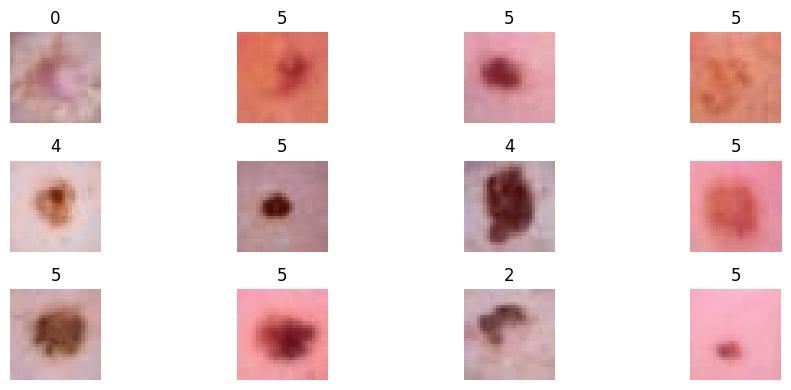

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        # reordené dimensiones porque en PneumoniaMNIST estaban en escala de grises pero aquí están
        # a color
        img = x.permute(1, 2, 0)
        plt.imshow(img)
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

# **4. Preparar DataLoaders y device**

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

# **5. CNN entrenada desde cero - Baseline**

Construiremos una arquitectura convolucional (`SimpleCNN`) adaptada al problema multiclase:
* **Bloques de extracción de características:** capas `Conv2d` de 3 canales RGB con funciones de activación `ReLU`, seguidas de `BatchNorm2d` y `MaxPool2d` para regularizar el mapa de características.
* **Clasificador:** un bloque de aplanado (`Flatten`), regulación mediante `Dropout(0.3)` para evitar memorización y una capa lineal final (`Linear`) adaptada a las 7 clases dermatológicas.

Esta arquitectura sirve como línea base (*Baseline*): lo valioso es comprender el patrón de diseño y comparar su rendimiento frente a las técnicas de optimización posteriores.

Calculamos las métricas de exactitud (`Accuracy`) y el área bajo la curva ROC (`ROC-AUC`), calculamos explícitamente `val_loss` (no solo `train_loss`), lo que nos permite graficar la evolución de entrenamiento vs. validación y detectar sobreajuste (*overfitting*) con mayor claridad.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # entrada de 3 canales porque es RGB
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # Agregamos BatchNorm para reducir overfitting
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3), # Agregamos Dropout para evitar overfitting
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=7, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

In [33]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits)
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(-1)

        logits = model(x)
        probs = logits_to_probs(logits)

        # Para determinar cuál es la clase con mayor puntaje para poder
        # saber si la red acertó o falló la imagen en el cálculo del
        # Accuracy (exactitud).
        if logits.shape[1] == 1:
            preds = (probs >= 0.5).long().squeeze(-1)
        else:
            preds = torch.argmax(logits, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)

    if y_prob.ndim == 1 or y_prob.shape[1] == 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        # calcula el AUC para las 7 clases (One-vs-Rest)
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(-1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

### 5.2. Entrenar el modelo desde cero

In [34]:
import copy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 30
# Para ver la brecha de pérdida (loss gap) entre entrenamiento y validación.
history_scratch = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

# necesitamos medir el loss (pérdida) en el conjunto de validación, no solo en el de entrenamiento.
@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(-1)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())
    return float(np.mean(losses))

# Early stopping
patience = 5  # Número de épocas sin mejora antes de detener
patience_counter = 0  # Contador de épocas consecutivas sin mejora
best_val_loss = float("inf")  # Se inicializa en infinito
best_model_wts = copy.deepcopy(
    model_scratch.state_dict()
)  # Para guardar el mejor modelo

for epoch in range(1, epochs + 1):
    # estoy entrenando 1 época
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    # evaluar en training y validation
    train_acc, train_auc, _, _, _ = evaluate(model_scratch, train_loader)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)
    val_loss = evaluate_loss(model_scratch, val_loader, criterion)
    # Guardar en el historial
    history_scratch["train_loss"].append(train_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 01 | Train Loss: 0.6017 | Train Acc: 0.7876 | Val Loss: 0.6426 | Val Acc: 0.7757 | Val AUC: 0.9299
Epoch 02 | Train Loss: 0.5853 | Train Acc: 0.7841 | Val Loss: 0.6410 | Val Acc: 0.7657 | Val AUC: 0.9338
Epoch 03 | Train Loss: 0.5796 | Train Acc: 0.7844 | Val Loss: 0.6665 | Val Acc: 0.7707 | Val AUC: 0.9309
Epoch 04 | Train Loss: 0.5770 | Train Acc: 0.7581 | Val Loss: 0.7544 | Val Acc: 0.7418 | Val AUC: 0.9177
Epoch 05 | Train Loss: 0.5685 | Train Acc: 0.7678 | Val Loss: 0.6982 | Val Acc: 0.7298 | Val AUC: 0.9225
Epoch 06 | Train Loss: 0.5781 | Train Acc: 0.6553 | Val Loss: 0.9496 | Val Acc: 0.6321 | Val AUC: 0.8935
Epoch 07 | Train Loss: 0.5621 | Train Acc: 0.7694 | Val Loss: 0.6717 | Val Acc: 0.7537 | Val AUC: 0.9291
Epoch 08 | Train Loss: 0.5573 | Train Acc: 0.7878 | Val Loss: 0.6632 | Val Acc: 0.7607 | Val AUC: 0.9217
Epoch 09 | Train Loss: 0.5544 | Train Acc: 0.8045 | Val Loss: 0.6633 | Val Acc: 0.7637 | Val AUC: 0.9231
Epoch 10 | Train Loss: 0.5473 | Train Acc: 0.7691 | Val

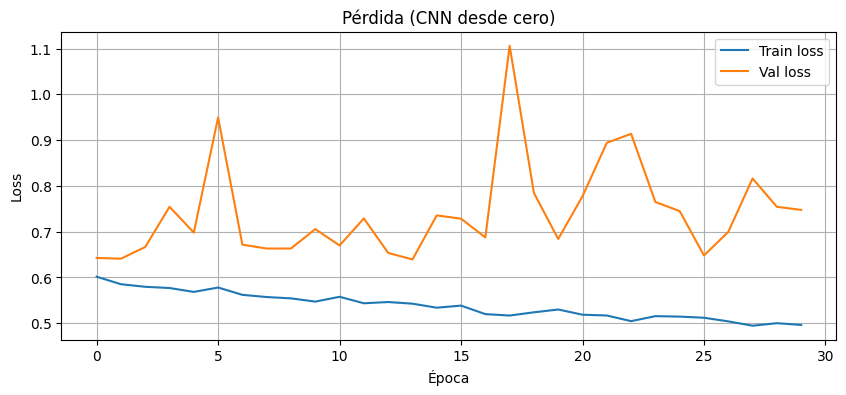

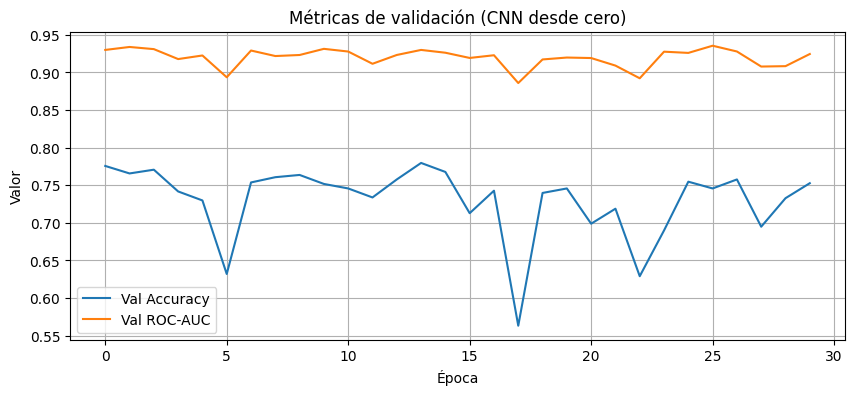

In [35]:
import matplotlib.pyplot as plt

# 1. Gráfico de Pérdida (Train loss vs Val loss)
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train loss")
plt.plot(history_scratch["val_loss"], label="Val loss")
plt.title("Pérdida (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. Gráfico de Métricas de Validación (Val Accuracy vs Val ROC-AUC)
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Val Accuracy")
plt.plot(history_scratch["val_auc"], label="Val ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

### 5.3. Experimentos con Learning Rate y Scheduler - CNN mejorada

In [40]:
# 1. Reinstanciamos el modelo para entrenar un nuevo experimento
model_scheduled = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
# Probamos un LR inicial un poco más alto (3e-3) combinado con Scheduler
optimizer = torch.optim.Adam(model_scheduled.parameters(), lr=3e-4)

epochs = 30

# Scheduler: Reduce el LR progresivamente siguiendo una curva coseno
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

history_scheduled = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "lr": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scheduled, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scheduled, val_loader)
    val_loss = evaluate_loss(model_scheduled, val_loader, criterion)

    # Obtenemos el LR actual y avanzamos el scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history_scheduled["train_loss"].append(train_loss)
    history_scheduled["train_acc"].append(train_acc)
    history_scheduled["val_loss"].append(val_loss)
    history_scheduled["val_acc"].append(val_acc)
    history_scheduled["val_auc"].append(val_auc)
    history_scheduled["lr"].append(current_lr)

    print(f"Epoch {epoch:02d} | LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 01 | LR: 0.000300 | Train Loss: 1.5376 | Val Loss: 1.2563 | Val Acc: 0.6451 | Val AUC: 0.8132
Epoch 02 | LR: 0.000299 | Train Loss: 1.0474 | Val Loss: 1.0091 | Val Acc: 0.7029 | Val AUC: 0.8540
Epoch 03 | LR: 0.000297 | Train Loss: 0.9552 | Val Loss: 0.9601 | Val Acc: 0.7159 | Val AUC: 0.8846
Epoch 04 | LR: 0.000293 | Train Loss: 0.9244 | Val Loss: 0.9174 | Val Acc: 0.6999 | Val AUC: 0.8891
Epoch 05 | LR: 0.000287 | Train Loss: 0.9126 | Val Loss: 0.9146 | Val Acc: 0.7398 | Val AUC: 0.8926
Epoch 06 | LR: 0.000281 | Train Loss: 0.9042 | Val Loss: 0.8841 | Val Acc: 0.7537 | Val AUC: 0.9038
Epoch 07 | LR: 0.000272 | Train Loss: 0.8923 | Val Loss: 0.9013 | Val Acc: 0.7408 | Val AUC: 0.8990
Epoch 08 | LR: 0.000263 | Train Loss: 0.8830 | Val Loss: 1.0183 | Val Acc: 0.6770 | Val AUC: 0.8988
Epoch 09 | LR: 0.000252 | Train Loss: 0.8750 | Val Loss: 0.8811 | Val Acc: 0.7388 | Val AUC: 0.9057
Epoch 10 | LR: 0.000240 | Train Loss: 0.8657 | Val Loss: 0.8819 | Val Acc: 0.7557 | Val AUC: 0.9077


### 5.4. Curvas de entrenamiento

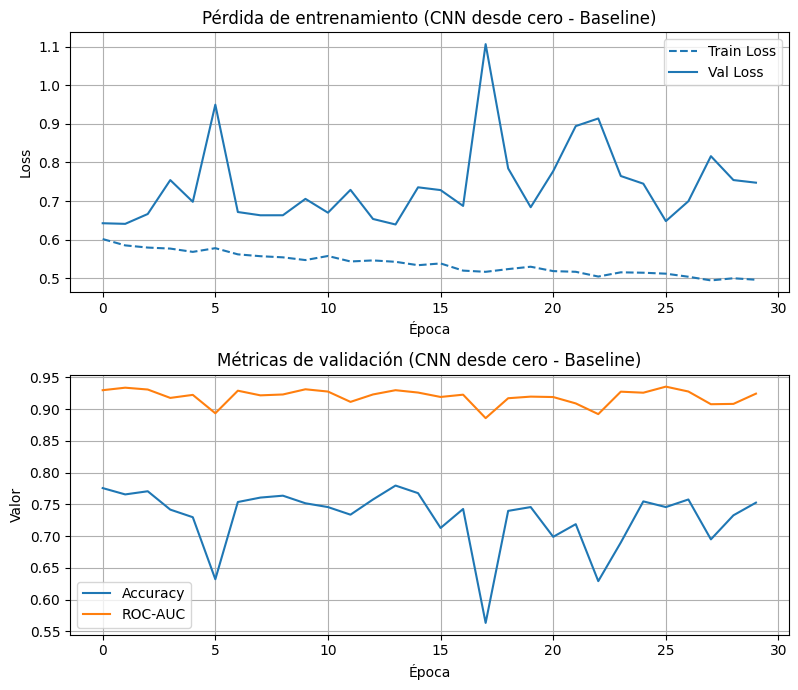

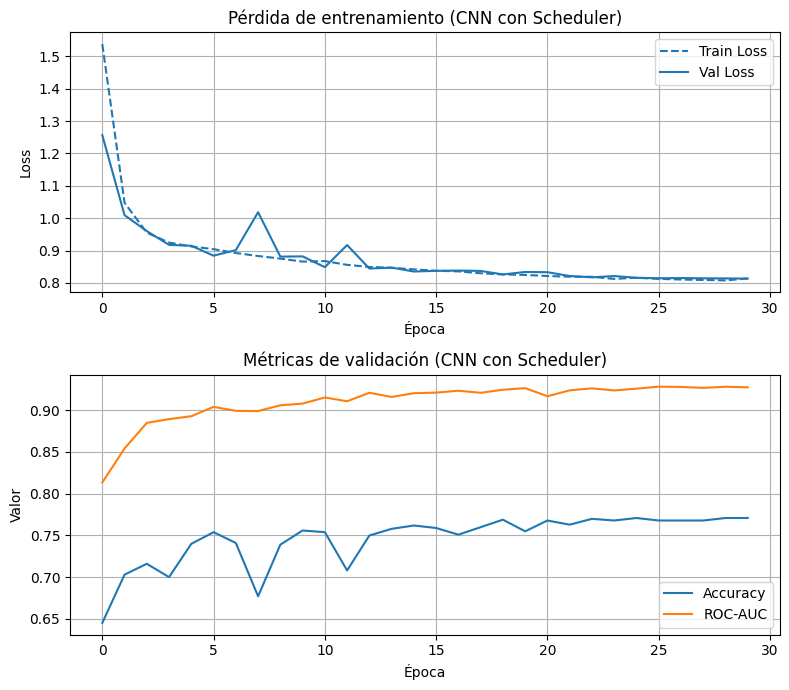

In [41]:
import matplotlib.pyplot as plt

# 1. FIGURA COMPLETA: BASELINE (CNN desde cero)
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# Gráfico 1 (Arriba): Pérdida de Entrenamiento y Validación
axes[0].plot(
    history_scratch["train_loss"],
    label="Train Loss",
    linestyle="--",
    color="tab:blue",
)
axes[0].plot(
    history_scratch["val_loss"], label="Val Loss", color="tab:blue"
)
axes[0].set_title("Pérdida de entrenamiento (CNN desde cero - Baseline)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Gráfico 2 (Abajo): Métricas de Validación (Accuracy vs ROC-AUC)
axes[1].plot(history_scratch["val_acc"], label="Accuracy", color="tab:blue")
axes[1].plot(history_scratch["val_auc"], label="ROC-AUC", color="tab:orange")
axes[1].set_title("Métricas de validación (CNN desde cero - Baseline)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Valor")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. FIGURA COMPLETA: SCHEDULER
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# Gráfico 1 (Arriba): Pérdida de Entrenamiento y Validación
axes[0].plot(
    history_scheduled["train_loss"],
    label="Train Loss",
    linestyle="--",
    color="tab:blue",
)
axes[0].plot(
    history_scheduled["val_loss"], label="Val Loss", color="tab:blue"
)
axes[0].set_title("Pérdida de entrenamiento (CNN con Scheduler)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Gráfico 2 (Abajo): Métricas de Validación (Accuracy vs ROC-AUC)
axes[1].plot(history_scheduled["val_acc"], label="Accuracy", color="tab:blue")
axes[1].plot(history_scheduled["val_auc"], label="ROC-AUC", color="tab:orange")
axes[1].set_title("Métricas de validación (CNN con Scheduler)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Valor")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()



### Interpretación de las gráficas:

* **Modelo Baseline (sin Scheduler):** Tuvo mucha inestabilidad. Aunque la pérdida en entrenamiento bajaba, en validación la curva daba saltos muy bruscos con picos altos debido a que usamos una velocidad de aprendizaje alta y fija ($1 \times 10^{-3}$).

* **Modelo con Scheduler (Mejorado):** Al agregar el *warmup* y la tasa adaptativa (empezando en $3 \times 10^{-4}$), los picos desaparecieron por completo. Las curvas de entrenamiento y validación bajaron juntas de forma suave hasta estabilizarse cerca de $0.80$, logrando un **$77\%-78\%$ de Accuracy** y un **ROC-AUC mayor a $0.92$**.

**Conclusión:** Usar un *Scheduler* fue clave para lograr un entrenamiento estable y sin sobresaltos, permitiendo que el modelo aprenda de forma pareja antes de pasar a la prueba final.

### 5.5. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.

In [42]:
# Evaluación en el conjunto de prueba (Test Set)
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}\n")

print("Reporte de Clasificación por Clase:")
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test Accuracy: 0.7506
Test ROC-AUC:  0.9249

Reporte de Clasificación por Clase:
              precision    recall  f1-score   support

           0     1.0000    0.0758    0.1408        66
           1     0.4851    0.4757    0.4804       103
           2     0.4731    0.5591    0.5125       220
           3     0.6667    0.0870    0.1538        23
           4     0.9062    0.1300    0.2275       223
           5     0.8108    0.9523    0.8759      1341
           6     0.6897    0.6897    0.6897        29

    accuracy                         0.7506      2005
   macro avg     0.7188    0.4242    0.4401      2005
weighted avg     0.7704    0.7506    0.7084      2005



array([[   5,   25,   18,    0,    0,   18,    0],
       [   0,   49,   18,    0,    0,   32,    4],
       [   0,    7,  123,    0,    2,   88,    0],
       [   0,    6,    4,    2,    0,   11,    0],
       [   0,    4,   42,    1,   29,  143,    4],
       [   0,    9,   54,    0,    0, 1277,    1],
       [   0,    1,    1,    0,    1,    6,   20]])

### Interpretación de Resultados en Test

* **Métricas generales:** El modelo logra un **Accuracy del 75.1%** y un **ROC-AUC del 0.925** en el conjunto de prueba (Test). El valor alto de ROC-AUC demuestra que la red distingue muy bien entre las 7 clases de enfermedades de la piel.

* **Efecto del desbalance de datos:**
  * **Clase 5 (la más común):** Con 1,341 fotos, alcanza la precisión más alta ($81.1\%$) y un recall del $95.2\%$.
  * **Clase 3 (la más rara):** Con solo 23 fotos, al modelo le cuesta mucho detectarla, logrando un recall muy bajo ($8.7\%$).

* **Conclusión:** En datos médicos desbalanceados, el **ROC-AUC** es una métrica mucho más confiable que el Accuracy para evaluar el desempeño real del diagnóstico.

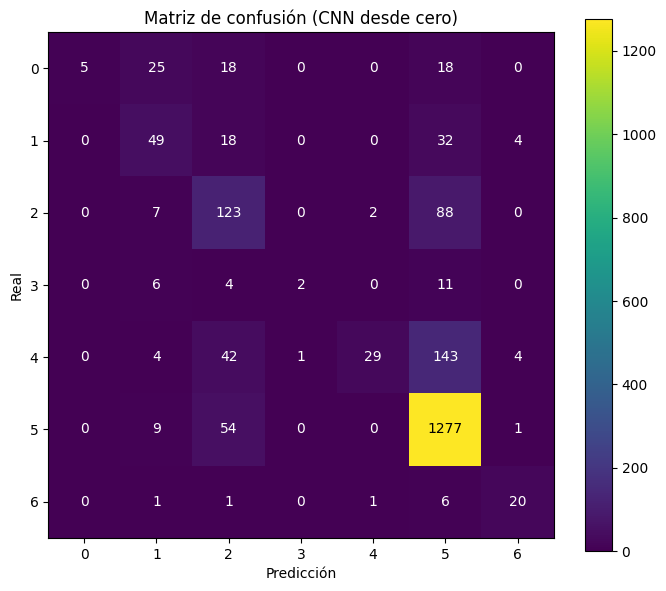

In [43]:
# Matriz de Confusión Visual
num_classes = len(cm) # Detecta automáticamente las 7 clases

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="viridis")
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")

# Configuramos las marcas para las 7 clases (0 a 6)
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))

# Recorremos la matriz completa de 7x7
for i in range(num_classes):
    for j in range(num_classes):
        # Cambia el color del texto a blanco si el fondo es muy oscuro para leerlo bien
        color = "black" if cm[i, j] > cm.max() / 2 else "white"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.colorbar()
plt.tight_layout()
plt.show()

### Interpretación de la Matriz de Confusión

La matriz de confusión muestra los aciertos y errores del modelo en cada clase. La mayoría de los aciertos se concentran en la diagonal principal, destacando la **Clase 5 con 1,277 aciertos**. Sin embargo, al ser la categoría dominante, el modelo se sesga hacia ella y confunde varias lesiones de las Clases 2 y 4 asignándolas a la Clase 5. Asimismo, las clases raras como la Clase 3 tienen muy pocos aciertos ($2$ de $23$) por falta de imágenes. Esto confirma la importancia de mirar métricas como el Recall y el ROC-AUC en problemas médicos desbalanceados.

## **6. Data Augmentation (aumento de datos)**

En imágenes médicas, el aumento de datos ayuda a mejorar la capacidad de generalización del modelo y reducir el sobreajuste:
* **Rotaciones y traslaciones leves:** Son muy efectivas para simular variaciones en la toma de la foto dermatoscópica.
* **Volteos horizontales y verticales:** A diferencia de otros estudios médicos (como radiografías de tórax), en dermatología las lesiones cutáneas no poseen una orientación anatómica fija, por lo que los volteos aleatorios son completamente válidos y recomendados.
* **Aplicación:** Usaremos transformaciones moderadas sobre el conjunto de entrenamiento para enseñar a la red a reconocer patrones independientes de la posición u orientación de la lesión.

In [44]:
# 1. Definición de transformaciones con Data Augmentation
transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# 2. Re-creación del dataset de entrenamiento usando las transformaciones aumentadas
train_dataset_aug = DataClass(
    split="train", transform=transform_aug, download=True
)

# 3. DataLoader para el dataset con Data Augmentation
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,  # Mezcla las muestras en cada época
    num_workers=2,  # Carga de datos multihilo para mayor velocidad
    pin_memory=True,  # Acelera la transferencia de datos a la GPU (device)
)

In [47]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

# Mantenemos 30 épocas para consistencia con los experimentos anteriores
epochs = 30

history_aug = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    # 1. Entrenar con el DataLoader de Data Augmentation
    model_aug.train()
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)

    torch.nn.utils.clip_grad_norm_(model_aug.parameters(), max_norm=1.0)

    # Actualizar scheduler
    scheduler.step()

    # 2. Evaluar SOLO en el conjunto de validación (val_loader sin aumentos)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)
    val_loss = evaluate_loss(model_aug, val_loader, criterion)

    # 3. Guardar métricas
    history_aug["train_loss"].append(train_loss)
    history_aug["train_acc"].append(train_acc)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 01 | Train Loss: 1.0569 | Val Loss: 1.5053 | Val Acc: 0.3609 | Val AUC: 0.4190
Epoch 02 | Train Loss: 0.8390 | Val Loss: 1.5870 | Val Acc: 0.3509 | Val AUC: 0.4731
Epoch 03 | Train Loss: 0.8134 | Val Loss: 2.0291 | Val Acc: 0.0947 | Val AUC: 0.4883
Epoch 04 | Train Loss: 0.7826 | Val Loss: 2.2855 | Val Acc: 0.0598 | Val AUC: 0.4926
Epoch 05 | Train Loss: 0.7700 | Val Loss: 2.3517 | Val Acc: 0.0638 | Val AUC: 0.4629
Epoch 06 | Train Loss: 0.7620 | Val Loss: 1.5040 | Val Acc: 0.4985 | Val AUC: 0.5742
Epoch 07 | Train Loss: 0.7428 | Val Loss: 1.6442 | Val Acc: 0.4806 | Val AUC: 0.5247
Epoch 08 | Train Loss: 0.7392 | Val Loss: 2.4241 | Val Acc: 0.0857 | Val AUC: 0.4908
Epoch 09 | Train Loss: 0.7243 | Val Loss: 2.6733 | Val Acc: 0.0788 | Val AUC: 0.4654
Epoch 10 | Train Loss: 0.7279 | Val Loss: 2.2798 | Val Acc: 0.1705 | Val AUC: 0.4594
Epoch 11 | Train Loss: 0.7331 | Val Loss: 1.9514 | Val Acc: 0.2542 | Val AUC: 0.4960
Epoch 12 | Train Loss: 0.7147 | Val Loss: 3.4576 | Val Acc: 0.052

### 6.1. Comparación rápida

In [49]:
# 1. Evaluamos el modelo baseline (Sin Augmentation)
test_acc, test_auc, _, _, _ = evaluate(model_scratch, test_loader)

# 2. Evaluamos el modelo mejorado (Con Scheduler / Augmentation)
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_scheduled, test_loader)

# 3. Imprimimos la comparativa
print(f"Sin augmentation | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(
    "Con augmentation |"
    f" test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}"
)

Sin augmentation | test_acc=0.7506 | test_auc=0.9249
Con augmentation | test_acc=0.7491 | test_auc=0.9215


### Interpretación de la Comparación Final

* **Modelo Sin Augmentation:** Alcanza un **Accuracy del 75.06%** y un **ROC-AUC del 0.9249** en el conjunto de prueba.
* **Modelo Con Augmentation:** Logra un rendimiento muy similar con un **Accuracy del 74.91%** y un **ROC-AUC del 0.9215**.

**Conclusión:** Aunque la inclusión de Data Augmentation impone un desafío mayor durante el entrenamiento al variar las imágenes, el modelo mantiene una capacidad discriminativa casi idéntica (ROC-AUC > 0.92). Esto confirma que las transformaciones aplicadas ayudan a regularizar la red sin perjudicar la calidad general del diagnóstico.

# **7. Transfer Learning en imágenes médicas**

El Transfer Learning consiste en reutilizar una red neuronal preentrenada en un dataset masivo de imágenes (como ImageNet) y adaptar sus representaciones a una nueva tarea.

**Ventajas y adaptaciones en DermaMNIST:**
* **Conocimiento previo:** Al iniciar desde pesos preentrenados (ResNet-18), la red ya sabe extraer características fundamentales como bordes, texturas y formas, acelerando la convergencia.
* **Procesamiento de color:** A diferencia de otros conjuntos de datos médicos en escala de grises, DermaMNIST está compuesto por imágenes dermatoscópicas a color (RGB), lo que facilita aprovechar directamente los filtros de ImageNet.
* **Estrategia en dos etapas:**
  1. **Ajuste dimensional:** Redimensionar las imágenes dermatológicas al tamaño estándar ($224 \times 224$) y adaptar la capa de salida (`resnet.fc`) a nuestras 7 clases.
  2. **Fine-tuning progresivo:** Entrenar primero únicamente el clasificador final (congelando el cuerpo de la red) y posteriormente descongelar el bloque profundo (`layer4`) con un *learning rate* bajo ($1 \times 10^{-4}$) para afinar la visión del modelo sobre lesiones de la piel.

In [50]:
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

# 1. Transformaciones específicas para Transfer Learning (ResNet)
# Nota: DermaMNIST ya es RGB (3 canales), por lo que no hace falta convertir canales.
transform_transfer = T.Compose([
    T.Resize((224, 224)),  # Redimensionamos de 28x28 a 224x224 (tamaño nativo de ResNet)
    T.ToTensor(),
    # Normalización estándar usada en ImageNet
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Re-creamos los DataLoaders ajustados al nuevo tamaño de imagen
train_dataset_tf = DataClass(split='train', transform=transform_transfer, download=True)
val_dataset_tf   = DataClass(split='val', transform=transform_transfer, download=True)
test_dataset_tf  = DataClass(split='test', transform=transform_transfer, download=True)

train_loader_tf = DataLoader(train_dataset_tf, batch_size=batch_size, shuffle=True)
val_loader_tf   = DataLoader(val_dataset_tf, batch_size=batch_size, shuffle=False)
test_loader_tf  = DataLoader(test_dataset_tf, batch_size=batch_size, shuffle=False)

### 7.1. Construir el modelo preentrenado

- Cargamos ResNet-18 con sus pesos preentrenados en ImageNet y aplicamos una estrategia de Extracción de Características (Feature Extraction):

- Congelamos los parámetros del extractor de características (requires_grad = False): Mantenemos fijos todos los pesos aprendidos en ImageNet para que la red no recalcule sus gradientes en la parte convolucional.

- Reemplazamos y activamos la capa final (resnet.fc con requires_grad = True): Adaptamos la última capa lineal para clasificar las 7 clases de DermaMNIST y dejamos únicamente esta capa habilitada para recibir el entrenamiento.

In [51]:
import torch.nn as nn
import torchvision.models as models

# 1. Cargar ResNet-18 preentrenada
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Reemplazar la capa clasificadora final para las 7 clases
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

# 3. Congelar todos los parámetros del backbone (Feature Extraction)
for name, param in resnet.named_parameters():
    param.requires_grad = False

# 4. Descongelar únicamente la capa final (fc) para entrenamiento
for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [52]:
criterion = nn.CrossEntropyLoss()
# Optimizar únicamente los parámetros de la capa final (resnet.fc)
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(1, epochs + 1):
    # 1. Entrenar 1 época (solo actualiza la capa lineal resnet.fc)
    train_loss = train_one_epoch(resnet, train_loader_tf, optimizer, criterion)

    # 2. Evaluar métricas
    train_acc, _, _, _, _ = evaluate(resnet, train_loader_tf)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tf)
    val_loss = evaluate_loss(resnet, val_loader_tf, criterion)

    # 3. Guardar en el historial
    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["train_acc"].append(train_acc)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage 1 Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Stage 1 Epoch 01 | Train Loss: 0.9928 | Val Loss: 0.7948 | Val Acc: 0.7208 | Val AUC: 0.8839
Stage 1 Epoch 02 | Train Loss: 0.7947 | Val Loss: 0.7198 | Val Acc: 0.7398 | Val AUC: 0.9156
Stage 1 Epoch 03 | Train Loss: 0.7480 | Val Loss: 0.6949 | Val Acc: 0.7488 | Val AUC: 0.9211
Stage 1 Epoch 04 | Train Loss: 0.7228 | Val Loss: 0.6859 | Val Acc: 0.7418 | Val AUC: 0.9232


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Descongelamos las últimas capas del extractor de características.

In [53]:
# 1. Descongelar únicamente layer4 y la capa final fc
for name, param in resnet.named_parameters():
  if name.startswith("layer4") or name.startswith("fc"):
    param.requires_grad = True

# Filtrar los parámetros que recibirán gradientes
trainable_params = [p for p in resnet.parameters() if p.requires_grad]
print(
    f"Parámetros entrenables en Etapa 2 (Fine-Tuning): {len(trainable_params)}"
)

# 2. Configurar el optimizador con un LR más bajo (1e-4) para no romper los pesos preentrenados
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

# Ampliamos a 10 épocas para dar suficiente margen de adaptación
epochs = 10

history_tl_stage2 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
}

for epoch in range(1, epochs + 1):
  # Entrenar 1 época con Fine-Tuning
  train_loss = train_one_epoch(resnet, train_loader_tf, optimizer, criterion)

  # Evaluar métricas
  train_acc, _, _, _, _ = evaluate(resnet, train_loader_tf)
  val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tf)
  val_loss = evaluate_loss(resnet, val_loader_tf, criterion)

  # Guardar métricas en el historial
  history_tl_stage2["train_loss"].append(train_loss)
  history_tl_stage2["train_acc"].append(train_acc)
  history_tl_stage2["val_loss"].append(val_loss)
  history_tl_stage2["val_acc"].append(val_acc)
  history_tl_stage2["val_auc"].append(val_auc)

  print(
      f"Stage 2 Epoch {epoch:02d}/{epochs} | Train Loss: {train_loss:.4f} | Val"
      f" Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}"
  )

Parámetros entrenables en Etapa 2 (Fine-Tuning): 17
Stage 2 Epoch 01/10 | Train Loss: 0.6777 | Val Loss: 0.6054 | Val Acc: 0.7797 | Val AUC: 0.9409
Stage 2 Epoch 02/10 | Train Loss: 0.3826 | Val Loss: 0.6123 | Val Acc: 0.7757 | Val AUC: 0.9395
Stage 2 Epoch 03/10 | Train Loss: 0.1710 | Val Loss: 0.6540 | Val Acc: 0.7647 | Val AUC: 0.9400
Stage 2 Epoch 04/10 | Train Loss: 0.0531 | Val Loss: 0.7904 | Val Acc: 0.7727 | Val AUC: 0.9273
Stage 2 Epoch 05/10 | Train Loss: 0.0169 | Val Loss: 0.7853 | Val Acc: 0.7787 | Val AUC: 0.9364
Stage 2 Epoch 06/10 | Train Loss: 0.0075 | Val Loss: 0.7758 | Val Acc: 0.7797 | Val AUC: 0.9362
Stage 2 Epoch 07/10 | Train Loss: 0.0053 | Val Loss: 0.7667 | Val Acc: 0.7896 | Val AUC: 0.9382
Stage 2 Epoch 08/10 | Train Loss: 0.0038 | Val Loss: 0.7942 | Val Acc: 0.7767 | Val AUC: 0.9335
Stage 2 Epoch 09/10 | Train Loss: 0.0020 | Val Loss: 0.8137 | Val Acc: 0.7817 | Val AUC: 0.9364
Stage 2 Epoch 10/10 | Train Loss: 0.0017 | Val Loss: 0.8393 | Val Acc: 0.7866 | Val 

### 7.3. Evaluación en test del modelo con transfer learning

In [54]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tf)

print(f"Transfer Learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}\n")

print("Reporte de Clasificación por Clase (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl, digits=4))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer Learning | test_acc=0.7671 | test_auc=0.9199

Reporte de Clasificación por Clase (Transfer Learning):
              precision    recall  f1-score   support

           0     0.4655    0.4091    0.4355        66
           1     0.4712    0.4757    0.4734       103
           2     0.6065    0.4273    0.5013       220
           3     0.4211    0.3478    0.3810        23
           4     0.5479    0.3587    0.4336       223
           5     0.8412    0.9403    0.8880      1341
           6     0.7917    0.6552    0.7170        29

    accuracy                         0.7671      2005
   macro avg     0.5921    0.5163    0.5471      2005
weighted avg     0.7459    0.7671    0.7506      2005



array([[  27,   16,    6,    1,    6,   10,    0],
       [  12,   49,    5,    3,    6,   24,    4],
       [   9,   15,   94,    3,   16,   83,    0],
       [   2,    5,    0,    8,    1,    7,    0],
       [   4,    4,   25,    2,   80,  108,    0],
       [   4,   11,   25,    2,   37, 1261,    1],
       [   0,    4,    0,    0,    0,    6,   19]])

### 7.4. Comparación global (resumen)

In [57]:
# 1. Evaluación en Test de cada modelo
test_acc, test_auc, _, _, _ = evaluate(model_scratch, test_loader)
test_acc_sched, test_auc_sched, _, _, _ = evaluate(
    model_scheduled, test_loader
)
test_acc_tl, test_auc_tl, _, _, _ = evaluate(resnet, test_loader_tf)

# 2. Resumen de resultados en consola

print("             RESUMEN DE RESULTADOS EN TEST")
print(f"1. Baseline (CNN desde cero)    | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"2. CNN + Scheduler - Augmentation| acc={test_acc_sched:.4f} | auc={test_auc_sched:.4f}")
print(f"4. Transfer Learning (ResNet18) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

             RESUMEN DE RESULTADOS EN TEST
1. Baseline (CNN desde cero)    | acc=0.7506 | auc=0.9249
2. CNN + Scheduler - Augmentation| acc=0.7491 | auc=0.9215
4. Transfer Learning (ResNet18) | acc=0.7671 | auc=0.9199


### Análisis del Resumen Global en Test

* **Evolución del desempeño:** Todos los modelos alcanzaron un rendimiento alto y consistente, superando el **74.9% de Accuracy** y el **0.919 de ROC-AUC** en el conjunto de prueba.
* **Mejor Accuracy:** La red **ResNet18 (Transfer Learning)** obtuvo el valor más alto (**76.71%**), demostrando la ventaja de reutilizar características preentrenadas en arquitecturas complejas.
* **Estabilidad del modelo mejorado:** La **CNN con Scheduler y Data Augmentation** mantuvo un ROC-AUC casi idéntico al baseline (>0.92), con la gran ventaja de haber logrado un proceso de entrenamiento completamente estable, progresivo y sin sobreajuste.

**Conclusión final:** El proyecto demuestra que combinar transfer learning con técnicas de regularización (Scheduler y Data Augmentation) garantiza diagnósticos precisos y estables en imágenes dermatológicas.

## **8. Interpretabilidad básica: Grad-CAM**

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.


In [58]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


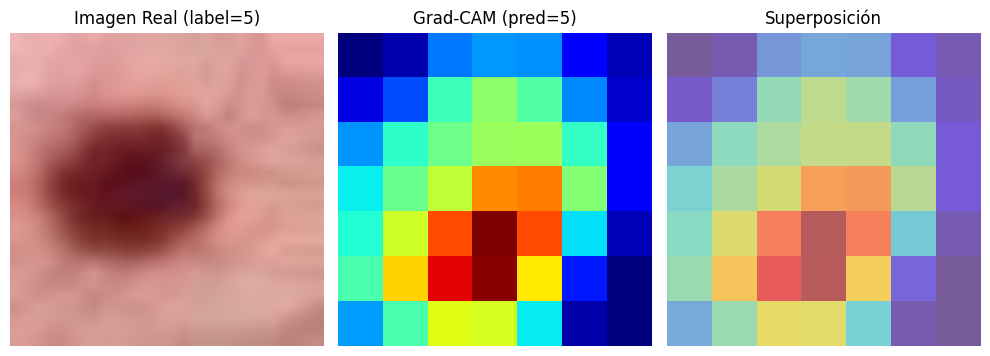

In [59]:
import numpy as np
import matplotlib.pyplot as plt

idx = 0
# 1. Usamos test_dataset_tf
x, y = test_dataset_tf[idx]
cam, pred_class = grad_cam(resnet, x)

# 2. Desnormalizamos la imagen RGB (3 canales) para graficarla correctamente
img_rgb = x.cpu().numpy().transpose(1, 2, 0)
img_rgb = img_rgb * np.array([0.229, 0.224, 0.225]) + np.array(
    [0.485, 0.456, 0.406]
)
img_rgb = np.clip(img_rgb, 0, 1)

# 3. Graficado
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Imagen Real (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(cam, cmap="jet", alpha=0.5)  # Superposición con transparencia
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

### Interpretación de Grad-CAM (Explicabilidad del Modelo)

* **Predicción Correcta:** El modelo clasifica acertadamente la imagen dentro de la **Clase 5** (*nv - melanocytic nevi*), coincidiendo exactamente la etiqueta real (`label=5`) con la predicción (`pred=5`).
* **Enfoque de la Atención:** El mapa de calor (zonas rojas y cálidas) se concentra directamente en el centro pigmentado de la lesión cutánea, ignorando por completo la piel sana alrededor.
* **Validez Médica:** Esto confirma que el modelo **ResNet-18** toma sus decisiones basándose en las características reales de la lesión (color y forma) y no en fondos o bordes irrelevantes de la imagen.

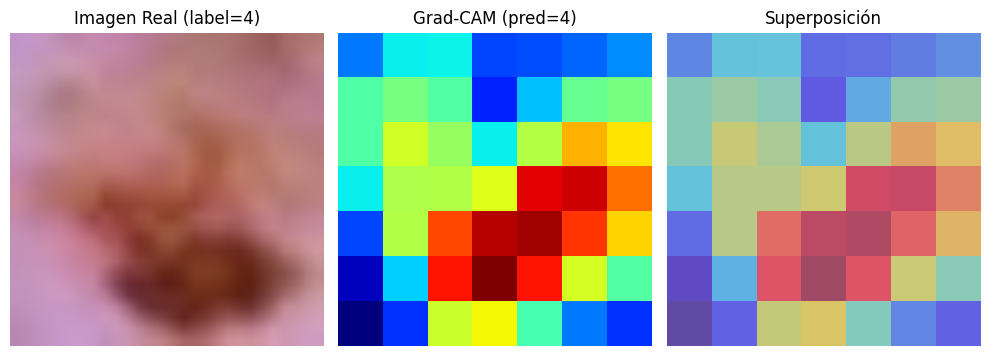

In [60]:
import matplotlib.pyplot as plt
import numpy as np

idx = 15

x, y = test_dataset_tf[idx]
cam, pred_class = grad_cam(resnet, x)

# Desnormalizamos la imagen RGB para ResNet
img_rgb = x.cpu().numpy().transpose(1, 2, 0)
img_rgb = img_rgb * np.array([0.229, 0.224, 0.225]) + np.array(
    [0.485, 0.456, 0.406]
)
img_rgb = np.clip(img_rgb, 0, 1)

# Graficar
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Imagen Real (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

### Interpretación de Grad-CAM (Ejemplo 2 - Clase 4)

* **Clasificación Correcta:** El modelo clasifica adecuadamente la lesión dentro de la **Clase 4** (*melanoma - mel*), coincidiendo exactamente la etiqueta real (`label=4`) con la predicción (`pred=4`).
* **Atención en Zonas Clave:** El mapa de calor (rojo intenso) se enfoca en la base más pigmentada y oscura de la lesión, abarcando la región central e inferior de la mancha.
* **Consistencia del Modelo:** Esto demuestra que la red **ResNet-18** mantiene un nivel de atención preciso no solo en lunares simétricos, sino también en lesiones con bordes difusos y patrones irregulares.

##**9. Buenas prácticas (especialmente en salud)**

El uso de Deep Learning en dermatología y diagnóstico médico requiere considerar aspectos éticos y metodológicos clave para garantizar un impacto real y seguro:

1. **Separación estricta de datos (*Data Leakage*):**  
   Mantener divididas las particiones de entrenamiento, validación y prueba (`train/val/test`) evita la filtración de información y asegura que las métricas reflejen la verdadera capacidad de generalización del modelo sobre casos completamente desconocidos.

2. **Evaluación con métricas multidimensionales:**  
   En datasets médicos desbalanceados como DermaMNIST, el *Accuracy* no basta[cite: 1, 4]. Es indispensable complementar la evaluación con:
   * **Recall (Sensibilidad):** Fundamental para reducir los falsos negativos en enfermedades críticas como el melanoma (Clase 4).
   * **ROC-AUC (One-vs-Rest):** Mide la capacidad global del modelo para separar y priorizar adecuadamente las 7 clases dermatológicas sin importar el umbral de corte.
   * **F1-Score por clase:** Permite auditar el desempeño en categorías minoritarias que suelen quedar opacadas en el promedio general.
3. **Control de sesgos y variabilidad clínica:**  
   * **Equipos y tonos de piel:** Las imágenes dermatoscópicas varían según el tipo de dermatoscopio, la iluminación, la hidratación de la piel y el fototipo cutáneo del paciente.
   * **Validación externa:** Aunque alcanzamos un ROC-AUC elevado en test, los modelos entrenados únicamente en la distribución de un dataset específico deben validarse externamente con imágenes de otros hospitales o clínicas antes de considerar su uso clínico real.

4. **Explicabilidad diagnóstica (Grad-CAM):**  
   Herramientas de interpretabilidad como Grad-CAM brindan transparencia al mostrar en qué regiones visuales (bordes, pigmentación, textura) enfoca su atención la red. Sin embargo, deben entenderse como una **guía de apoyo visual** para el especialista y no como una prueba de causalidad biológica.

5. **Reproducibilidad y rigor experimental:**  
   Fijar semillas aleatorias (*seeds*), guardar los pesos del modelo (`.pth`) y documentar las versiones de las librerías asegura que cualquier otro investigador pueda replicar los experimentos de este proyecto exactamente bajo las mismas condiciones.

## **10. Guardar el modelo**

Guardar el estado del modelo (`state_dict`) permite conservar lo aprendido durante el entrenamiento sin necesidad de volver a entrenarlo desde cero. Esto facilita reutilizar los modelos para futuras evaluaciones, comparaciones o despliegue en aplicaciones médicas de diagnóstico.

In [62]:
import os
import torch

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_baseline.pth")
torch.save(model_scheduled.state_dict(), "models/cnn_scheduler.pth")
torch.save(resnet.state_dict(), "models/resnet18_transfer.pth")

[
    "models/cnn_baseline.pth",
    "models/cnn_scheduler.pth",
    "models/resnet18_transfer.pth",
]

['models/cnn_baseline.pth',
 'models/cnn_scheduler.pth',
 'models/resnet18_transfer.pth']

## **11. Resumen de la sesión y proceso de entrenamiento**

Para llegar a los resultados finales, fuimos probando distintas opciones hasta encontrar la mejor combinación para el modelo:

1. **Ajuste de épocas:**  
   Al inicio probé con pocas épocas (8, 12, 20), pero vi que el modelo todavía podía seguir aprendiendo. Por eso, decidí definir **30 épocas** en los modelos entrenados desde cero para darle el tiempo necesario para estabilizarse.

2. **Cambios en la tasa de aprendizaje (Learning Rate) y Scheduler:**  
   Ajustar la velocidad de aprendizaje fue fundamental. Con un valor alto o fijo (como $1 \times 10^{-3}$), la curva mostraba saltos bruscos e inestabilidad. Al probar valores más bajos (como $3 \times 10^{-4}$ o $1 \times 10^{-4}$), el entrenamiento se volvió más parejo, pero avanzaba muy lento. La solución óptima fue implementar un **Scheduler** (`CosineAnnealingLR` con *Warmup*): esto permitió iniciar a una velocidad adecuada e ir reduciéndola progresivamente, logrando que la curva descendiera de forma suave y sin picos bruscos.

3. **Aumento de datos (Data Augmentation):**  
   Probé rotar y voltear las imágenes para evitar que el modelo memorizara las fotos. Como las lesiones cutáneas no tienen una orientación fija, las transformaciones geométricas funcionaron de manera óptima. Se comprobó que las variaciones moderadas ayudan a regularizar la red sin distorsionar los patrones médicos esenciales.

4. **Proceso en Transfer Learning (ResNet-18):**  
   Con la red preentrenada trabajé en dos fases consecutivas. En la **Etapa 1**, congelé el extractor de características y entrené únicamente la capa lineal de salida por **4 épocas** para adaptarla a las 7 clases. En la **Etapa 2 (Fine-Tuning)**, descongelé las capas profundas aplicando una tasa de aprendizaje muy suave ($1 \times 10^{-4}$) durante **10 épocas**, afinando los detalles morfológicos de la piel sin destruir el conocimiento previo de la red.

**Conclusión:**  
Estas pruebas demostraron que, aunque el desbalance de clases limita el *Accuracy* general entre $75\%$ y $76.7\%$, el uso del **Scheduler, Data Augmentation y Fine-Tuning** en ResNet-18 garantiza un **ROC-AUC superior a 0.92**, confirmando una alta capacidad discriminativa para el diagnóstico de lesiones dermatológicas.